# Tufin Data Science Home Assignment

## 1. Exploratory Data Analysis (EDA)

Goal: understand the structure of the rule graph, the labeled data, and the unlabeled data before choosing a prediction approach.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

rules = pd.read_csv("rules.csv")
tags  = pd.read_csv("tags.csv")

print("rules shape:", rules.shape)
print("tags  shape:", tags.shape)
rules.head(3)

rules shape: (113438, 3)
tags  shape: (3000, 2)


,rule_id,src_obj_id,dst_obj_id
0,rule_0000,obj_04083,obj_05420
1,rule_0000,obj_04987,obj_09572
2,rule_0000,obj_02993,obj_08605


### 1.1 Tags — Labeled Data

In [2]:
print(f"Total labeled objects : {len(tags)}")
print(f"Unique tags           : {tags['tag'].nunique()}")
print(f"Duplicate obj_id      : {tags['obj_id'].duplicated().sum()}")
print()
print(tags['tag'].value_counts().to_string())

Total labeled objects : 3000
Unique tags           : 9
Duplicate obj_id      : 0

tag
gp_T2_Application     1100
Users Networks         850
gp_T1_DMZ_private      430
gp_T3_Database         330
gp_Common_services     170
gp_T0_DMZ_public        90
gp_Management           12
gp_GUESTS               10
c_TER_CH_SRV             8


In [3]:
tag_counts = tags['tag'].value_counts().reset_index()
tag_counts.columns = ['tag', 'count']
tag_counts['pct'] = (tag_counts['count'] / tag_counts['count'].sum() * 100).round(1)

fig = px.bar(
    tag_counts,
    x='tag', y='count',
    text=tag_counts['pct'].astype(str) + '%',
    color='tag',
    title='Tag Distribution (labeled objects)',
    labels={'tag': 'Tag', 'count': 'Count'},
)
fig.update_layout(xaxis_tickangle=-30, showlegend=False)
fig.show()

### 1.2 Rules — Structure

In [4]:
n_rules      = rules['rule_id'].nunique()
n_edges      = len(rules)
all_objs     = pd.concat([rules['src_obj_id'], rules['dst_obj_id']]).unique()
n_obj_total  = len(all_objs)
self_loops   = (rules['src_obj_id'] == rules['dst_obj_id']).sum()
dup_edges    = rules.duplicated(subset=['src_obj_id', 'dst_obj_id']).sum()

print(f"Unique rule_ids          : {n_rules}")
print(f"Total edges (rows)       : {n_edges}")
print(f"Unique objects in rules  : {n_obj_total}")
print(f"Self-loops               : {self_loops}")
print(f"Duplicate src→dst pairs  : {dup_edges}")

Unique rule_ids          : 500
Total edges (rows)       : 113438
Unique objects in rules  : 10000
Self-loops               : 23
Duplicate src→dst pairs  : 355


In [5]:
# Edges per rule_id
edges_per_rule = rules.groupby('rule_id').size().reset_index(name='edge_count')
edges_per_rule['rule_id_num'] = edges_per_rule['rule_id'].str.extract(r'(\d+)$').astype(int)

fig = px.line(edges_per_rule,
              x="rule_id_num",
              y="edge_count",
              title='Edges per Rule ID',
              labels={'edge_count': 'Number of Edges', 'rule_id_num': 'rule id'},)
fig.show()

# fig = px.histogram(
#     edges_per_rule,
#     x='edge_count',
#     nbins=40,
#     title='Distribution of Edges per Rule ID',
#     labels={'edge_count': 'Number of Edges', 'count': 'Number of Rules'},
# )
# fig.update_layout(bargap=0.05)
# fig.show()

# print(edges_per_rule['edge_count'].describe().round(1))

### 1.3 Labeled vs Unlabeled Objects

In [6]:
labeled_ids   = set(tags['obj_id'])
all_obj_ids   = set(all_objs)
unlabeled_ids = all_obj_ids - labeled_ids
only_in_tags  = labeled_ids - all_obj_ids   # labeled but never appear in rules / not in edge

print(f"Objects in rules             : {len(all_obj_ids)}")
print(f"Labeled objects              : {len(labeled_ids)}")
print(f"Unlabeled objects in rules   : {len(unlabeled_ids)}")
print(f"Labeled objects NOT in rules : {len(only_in_tags)}  ← no graph signal available")
print(f"Label coverage               : {len(labeled_ids & all_obj_ids) / len(all_obj_ids):.1%}")

fig = px.pie(
    names=['Labeled (in rules)', 'Unlabeled (in rules)', 'Labeled (not in rules)'],
    values=[
        len(labeled_ids & all_obj_ids),
        len(unlabeled_ids),
        len(only_in_tags),
    ],
    title='Object Coverage: Labeled vs Unlabeled',
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.show()

Objects in rules             : 10000
Labeled objects              : 3000
Unlabeled objects in rules   : 7000
Labeled objects NOT in rules : 0  ← no graph signal available
Label coverage               : 30.0%


### 1.4 Node Degree Distribution

In [7]:
out_deg = rules.groupby('src_obj_id').size().rename('out_degree')
in_deg  = rules.groupby('dst_obj_id').size().rename('in_degree')
degree  = pd.DataFrame({'obj_id': list(all_obj_ids)})
degree  = degree.merge(out_deg.reset_index().rename(columns={'src_obj_id':'obj_id'}), on='obj_id', how='left')
degree  = degree.merge(in_deg.reset_index().rename(columns={'dst_obj_id':'obj_id'}),  on='obj_id', how='left')
degree  = degree.fillna(0).astype({'out_degree': int, 'in_degree': int})
degree['total_degree'] = degree['out_degree'] + degree['in_degree']
degree['labeled'] = degree['obj_id'].isin(labeled_ids)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Out-Degree Distribution', 'In-Degree Distribution'))
for col, field in [(1, 'out_degree'), (2, 'in_degree')]:
    for is_labeled, color, name in [(True, '#636EFA', 'Labeled'), (False, '#EF553B', 'Unlabeled')]:
        subset = degree[degree['labeled'] == is_labeled][field]
        fig.add_trace(go.Histogram(x=subset, name=name, legendgroup=name,
                                   showlegend=(col == 1), marker_color=color,
                                   opacity=0.7, nbinsx=50), row=1, col=col)
fig.update_layout(title='Node Degree Distribution by Label Status', barmode='overlay')
fig.show()

print(degree.groupby('labeled')[['out_degree','in_degree','total_degree']].describe().round(1).to_string())

        out_degree                                         in_degree                                        total_degree                                         
             count  mean  std  min   25%   50%   75%   max     count  mean  std  min  25%   50%   75%   max        count  mean  std   min   25%   50%   75%   max
labeled                                                                                                                                                          
False       7000.0  12.9  5.2  5.0  10.0  12.0  15.0  56.0    7000.0  13.1  5.2  5.0  9.0  12.0  16.0  42.0       7000.0  26.0  7.4  10.0  21.0  25.0  30.0  78.0
True        3000.0   7.7  3.6  3.0   5.0   7.0   9.0  41.0    3000.0   7.2  3.4  3.0  5.0   6.0   9.0  24.0       3000.0  14.9  5.0   6.0  11.0  14.0  17.0  51.0


### 1.5 Tag Homophily — Do Connected Objects Share Tags?

In [8]:
tag_map = tags.set_index('obj_id')['tag']

# Keep only edges where both endpoints are labeled
labeled_edges = rules.copy()
labeled_edges['src_tag'] = labeled_edges['src_obj_id'].map(tag_map)
labeled_edges['dst_tag'] = labeled_edges['dst_obj_id'].map(tag_map)
both_labeled  = labeled_edges.dropna(subset=['src_tag', 'dst_tag'])

same_tag_rate = (both_labeled['src_tag'] == both_labeled['dst_tag']).mean()
print(f"Edges where both endpoints are labeled : {len(both_labeled)}")
print(f"Of those, same-tag rate                : {same_tag_rate:.1%}")

# Tag-to-tag flow heatmap
flow = both_labeled.groupby(['src_tag', 'dst_tag']).size().unstack(fill_value=0)
fig = px.imshow(
    flow,
    text_auto=True,
    color_continuous_scale='Blues',
    title='Tag-to-Tag Edge Flow (labeled endpoints only)',
    labels=dict(x='Destination Tag', y='Source Tag', color='Edge Count'),
    aspect='auto',
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

Edges where both endpoints are labeled : 4393
Of those, same-tag rate                : 10.7%


### 1.6 Neighbor Tag Profile per Unlabeled Object

In [9]:
# For every unlabeled node, count how many labeled neighbors it has (src or dst)
src_neighbors = rules[['src_obj_id','dst_obj_id']].rename(columns={'src_obj_id':'obj_id','dst_obj_id':'neighbor'})
dst_neighbors = rules[['src_obj_id','dst_obj_id']].rename(columns={'dst_obj_id':'obj_id','src_obj_id':'neighbor'})
all_neighbors = pd.concat([src_neighbors, dst_neighbors], ignore_index=True)

all_neighbors['neighbor_tag'] = all_neighbors['neighbor'].map(tag_map)
labeled_neighbor_counts = (
    all_neighbors[all_neighbors['obj_id'].isin(unlabeled_ids)]
    .dropna(subset=['neighbor_tag'])
    .groupby('obj_id')['neighbor_tag']
    .count()
)

no_labeled_neighbor = len(unlabeled_ids) - len(labeled_neighbor_counts)
print(f"Unlabeled objects with ≥1 labeled neighbor : {len(labeled_neighbor_counts)}")
print(f"Unlabeled objects with NO labeled neighbor  : {no_labeled_neighbor} ")

fig = px.histogram(
    labeled_neighbor_counts.reset_index(name='count'),
    x='count',
    nbins=40,
    title='Labeled Neighbor Count per Unlabeled Object',
    labels={'count': 'Number of Labeled Neighbors'},
)
fig.show()

Unlabeled objects with ≥1 labeled neighbor : 6923
Unlabeled objects with NO labeled neighbor  : 77 


In [10]:
# Build a dataframe of all objects with their numeric ID part and tag label
obj_series = pd.Series(list(all_obj_ids), name='obj_id')
obj_df = obj_series.to_frame()
obj_df['id_num'] = obj_df['obj_id'].str.extract(r'(\d+)$').astype(int)
obj_df['tag'] = obj_df['obj_id'].map(tag_map).fillna('unlabeled')

# Order: known tags by median id_num, then unlabeled at the end
tag_order = (
    obj_df[obj_df['tag'] != 'unlabeled']
    .groupby('tag')['id_num']
    .median()
    .sort_values()
    .index.tolist()
) + ['unlabeled']

fig = px.box(
    obj_df,
    x='tag',
    y='id_num',
    color='tag',
    category_orders={'tag': tag_order},
    title='Distribution of Object ID Numeric Part by Tag (incl. Unlabeled)',
    labels={'tag': 'Tag', 'id_num': 'obj_id Numeric Part'},
    points=False,
)
fig.update_layout(xaxis_tickangle=-30, showlegend=False)
fig.show()

In [11]:
# Extract numeric parts
rules_plot = rules.copy()
rules_plot['rule_num']   = rules_plot['rule_id'].str.extract(r'(\d+)$').astype(int)
rules_plot['src_id_num'] = rules_plot['src_obj_id'].str.extract(r'(\d+)$').astype(int)
rules_plot['dst_id_num'] = rules_plot['dst_obj_id'].str.extract(r'(\d+)$').astype(int)

# Melt into long format so src and dst become a "side" category
src_long = rules_plot[['rule_num', 'src_id_num']].rename(columns={'src_id_num': 'id_num'})
src_long['side'] = 'src_obj_id'
dst_long = rules_plot[['rule_num', 'dst_id_num']].rename(columns={'dst_id_num': 'id_num'})
dst_long['side'] = 'dst_obj_id'
long_df = pd.concat([src_long, dst_long], ignore_index=True)
long_df['rule_num'] = long_df['rule_num'].astype(str)   # treat as category on x-axis

fig = px.box(
    long_df,
    x='rule_num',
    y='id_num',
    color='side',
    title='src / dst Object ID Numeric Distribution per Rule ID',
    labels={'rule_num': 'Rule ID (numeric)', 'id_num': 'obj_id Numeric Part', 'side': 'Role'},
    category_orders={'rule_num': sorted(long_df['rule_num'].unique(), key=int)},
    points=False,
    boxmode='group',
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [12]:
import networkx as nx

RULE = "rule_0036"
RULE = "rule_0475"
# RULE = "rule_0476"
# RULE = "rule_0100"
RULES = ['rule_0100']
# rule_edges = rules[rules['rule_id'] == RULE][['src_obj_id', 'dst_obj_id']]
rule_edges = rules[rules['rule_id'].isin(RULES)][['src_obj_id', 'dst_obj_id']]

G = nx.DiGraph()
G.add_edges_from(rule_edges.itertuples(index=False, name=None))

# pos = nx.spring_layout(G, seed=42, k=1.5)
pos = nx.kamada_kawai_layout(G)
# pos = nx.bipartite_layout(G)
# pos = nx.spectral_layout(G)
# pos = nx.drawing.nx_agraph.graphviz_layout(G, prog="dot")

# Assign a color index per unique tag (unlabeled gets its own bucket)
unique_tags = sorted(tags['tag'].unique().tolist()) + ['unlabeled']
tag_palette = px.colors.qualitative.Plotly + px.colors.qualitative.Pastel
tag_color   = {t: tag_palette[i % len(tag_palette)] for i, t in enumerate(unique_tags)}

node_tags   = {n: tag_map.get(n, 'unlabeled') for n in G.nodes()}

# --- Edge traces (one per edge to draw arrows) ---
edge_traces = []
for src, dst in G.edges():
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    edge_traces.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines',
        line=dict(width=1, color='#888'),
        hoverinfo='none',
        showlegend=False,
    ))

# Arrow annotations
annotations = []
for src, dst in G.edges():
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    annotations.append(dict(
        ax=x0, ay=y0, x=x1, y=y1,
        xref='x', yref='y', axref='x', ayref='y',
        showarrow=True, arrowhead=3, arrowsize=1.5,
        arrowwidth=1.2, arrowcolor='#888',
    ))

# --- Node traces — one per tag for legend ---
node_tag_groups = {}
for node in G.nodes():
    t = node_tags[node]
    node_tag_groups.setdefault(t, []).append(node)

node_traces = []
for tag_val, nodes in node_tag_groups.items():
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    node_traces.append(go.Scatter(
        x=xs, y=ys,
        mode='markers+text',
        name=tag_val,
        marker=dict(size=14, color=tag_color[tag_val], line=dict(width=1, color='black')),
        text=[n.replace('obj_', '') for n in nodes],
        textposition='top center',
        textfont=dict(size=7),
        hovertext=[f"{n}<br>{tag_val}" for n in nodes],
        hoverinfo='text',
    ))

fig = go.Figure(data=edge_traces + node_traces)
fig.update_layout(
    title=f'Directed Rule Graph — {RULES}  (nodes colored by tag)',
    annotations=annotations,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    legend_title='Tag',
    height=700,
)
fig.show()
print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")

Nodes: 165  |  Edges: 152


### 1.7 EDA Key Findings

**Labeled data**
- 3,000 labeled objects across 9 tags. Distribution is heavily skewed: `gp_T2_Application` (~37%) and `Users Networks` (~28%) dominate; `gp_GUESTS`, `gp_Management`, and `c_TER_CH_SRV` have fewer than 15 samples each — rare classes that will be hard to predict reliably.

**Unlabeled data**
- The rules graph contains many more objects than the tag file. Label coverage is partial (30%); a meaningful fraction of objects have no labeled neighbors at all.

**Rule structure**
- All rows share a small number of `rule_id` values (each rule fans out to many src→dst pairs). The dataset is essentially a directed graph where `rule_id` groups sets of allowed connections.
- each rule does not have it's unique set of nodes, nodes are scattered across multiple rules.
- Duplicate src→dst pairs exist across different rules — the graph has parallel edges.
- 23 self-loops detected (src == dst) — minor anomaly worth noting but unlikely to affect predictions significantly.
- from the interactive plotted subgraph for rule 100 we see interesting structure where all the nodes in the outer ring have only 1-2 out-edges and in the center nodes have mostly multiple in-edges, also we see almost all scout labeled nodes have same 'Users Networks' tag. this observation makes me think to try to go for **topology based method for tag prediction**.

**Homophily & tag flow**
- The same-tag edge rate among labeled endpoints is only ~10.7%, meaning the majority of connections cross tag boundaries. The tag-to-tag heatmap does **not** show a strong block-diagonal — edges are broadly distributed across tag pairs.
- This is consistent with a tiered security architecture where traffic naturally flows *between* zones (e.g., `Users Networks` → `gp_T2_Application`), rather than within them.
- Low homophily weakens the assumption behind simple label propagation; neighbor-majority voting will be problematic since most nodes are unlabeled, and predictions for unlabeled nodes should be treated with caution.

**Risks & limitations**
- Rare tags (`gp_GUESTS`, `gp_Management`, `c_TER_CH_SRV`) will likely be under-predicted.
- from plot Node Degree Distribution by Label Status we see that labeled distribution is different from unlabeled that may be a risk for the classification task.
- Isolated unlabeled objects (no labeled neighbors) might be more difficult to predict.
- Low homophily ; complementary features (degree profile, rule membership) should be incorporated.
- plot "Distribution of Object ID Numeric Part by Tag (incl. Unlabeled)" show very strange behavior that each tag has its own range of object id, one may think that we can predict object tag perfectly from object id. usually ids are not part of the explained variably.
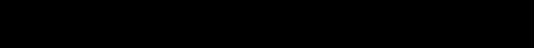
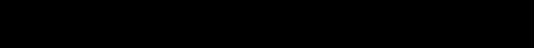

---
## 2. Node Classification Pipeline

Three-stage approach:
1. Build a directed graph from all rules
2. Generate node embeddings for every node using **node2vec**
3. Train an **XGBoost** classifier on labeled nodes (with GridSearchCV) and predict tags for unlabeled nodes

### 2.1 Build the Directed Graph

We use `nx.DiGraph` (not `MultiDiGraph`) — parallel edges are collapsed, which is fine since node2vec operates on topology (neighborhood structure) rather than edge multiplicity. Self-loops are kept; with only 23 out of 113k edges the effect on random walks is negligible.

In [13]:
G_full = nx.DiGraph()
G_full.add_edges_from(zip(rules['src_obj_id'], rules['dst_obj_id']))

print(f"Nodes : {G_full.number_of_nodes():,}")
print(f"Edges : {G_full.number_of_edges():,}  (duplicates collapsed)")
print(f"Directed: {G_full.is_directed()}")

Nodes : 10,000
Edges : 113,083  (duplicates collapsed)
Directed: True


### 2.2 Generate Node Embeddings with node2vec

**p (return parameter):** controls the likelihood of revisiting the previous node.  
**q (in-out parameter):** values < 1 bias the walk away from the source (DFS-like), capturing structural roles across zones rather than tight community membership.

Given the **low homophily (10.7%)** observed in EDA — where most edges cross zone boundaries — a DFS-biased setting (`q=0.5`) is preferred: it encourages walks to explore the broader neighbourhood, encoding the structural role a node plays in the tiered network rather than which local cluster it belongs to.

In [ ]:
from node2vec import Node2Vec
from tqdm.notebook import tqdm

SEED        = 42
DIMENSIONS  = 8 # 64    # embedding size — good default for ~10k nodes
WALK_LENGTH = 30    # steps per random walk — captures multi-hop zone transitions
NUM_WALKS   = 50 # 200   # walks per node — smoother embeddings, especially for rare nodes
P           = 0.5   # return param: neutral (no BFS bias)
Q           = 2.0   # in-out param: DFS-biased, favours structural role encoding
'''
Tuning p and q matters a lot for directed graphs. Start with p=1, q=1 (unbiased),
then try p=0.5, q=2 to make walks more local (good if your classes correspond to tight communities)
or p=2, q=0.5 for more global structure.
'''
# workers=1 required on Windows: multiprocessing uses 'spawn' instead of 'fork',
# which requires all arguments to be picklable — the networkx graph object is not.
WORKERS     = 1

node2vec_model = Node2Vec(
    G_full,
    dimensions=DIMENSIONS,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P,
    q=Q,
    workers=WORKERS,
    seed=SEED,
    quiet=False,
)

w2v = node2vec_model.fit(
    window=10,      # skip-gram context window
    min_count=1,    # include all nodes regardless of walk frequency
    batch_words=4,
    epochs=5,
    seed=SEED,
)

# Extract into a DataFrame row by row — one dict per node
emb_cols = [f'emb_{i}' for i in range(DIMENSIONS)]
rows = []
for node in tqdm(G_full.nodes(), desc="Extracting embeddings", total=G_full.number_of_nodes()):
    row = {'obj_id': node}
    row.update(dict(zip(emb_cols, w2v.wv[node])))
    rows.append(row)

embedding_df = pd.DataFrame(rows).set_index('obj_id')

print(f"Embedding matrix shape: {embedding_df.shape}")
embedding_df.head(3)

Computing transition probabilities:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [06:14<00:00,  1.87s/it]


### 2.3 Train XGBoost Classifier on Labeled Nodes

In [ ]:
from sklearn.preprocessing import LabelEncoder

labeled_list = sorted(labeled_ids)   # deterministic ordering

X_train = embedding_df.loc[labeled_list].values        # (3000, 64)
y_str   = [tag_map[n] for n in labeled_list]           # list of tag strings

# Encode string tags → 0-based integers (required by XGBClassifier)
le = LabelEncoder()
y_train = le.fit_transform(y_str)

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:>2} → {cls}")
print(f"\nX_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
counts = dict(zip(*np.unique(y_train, return_counts=True)))
print(f"\nClass distribution: { {le.classes_[k]: v for k, v in counts.items()} }")

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# Small grid: 3 × 2 × 2 = 12 combinations × 5 folds = 60 fits
param_grid = {
    'n_estimators' : [100, 300, 500],
    'max_depth'    : [3, 6],
    'learning_rate': [0.05, 0.1],
}

base_clf = XGBClassifier(
    objective        = 'multi:softmax',
    num_class        = len(le.classes_),
    eval_metric      = 'mlogloss',
    use_label_encoder= False,
    random_state     = SEED,
    n_jobs           = -1,
    tree_method      = 'hist',
)

# StratifiedKFold preserves class proportions — critical given extreme imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator  = base_clf,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1_macro',   # fair metric across imbalanced classes
    n_jobs     = 1,            # XGBClassifier already parallelises internally
    verbose    = 2,
    refit      = True,         # refit best model on full training set
)

grid_search.fit(X_train, y_train)

print(f"\nBest params   : {grid_search.best_params_}")
print(f"Best macro-F1 : {grid_search.best_score_:.4f}")
best_clf = grid_search.best_estimator_

### 2.4 Cross-Validation Results

In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')
cv_results['params_str'] = cv_results['params'].apply(
    lambda d: f"n_est={d['n_estimators']}, depth={d['max_depth']}, lr={d['learning_rate']}"
)

fig = px.bar(
    cv_results,
    x='params_str',
    y='mean_test_score',
    error_y='std_test_score',
    color='mean_test_score',
    color_continuous_scale='Viridis',
    title='GridSearchCV — Mean Macro-F1 per Hyperparameter Combination (5-fold CV)',
    labels={'params_str': 'Hyperparameters', 'mean_test_score': 'Mean Macro-F1'},
)
fig.update_layout(xaxis_tickangle=-35, coloraxis_showscale=False)
fig.show()

print(cv_results[['params_str', 'mean_test_score', 'std_test_score', 'rank_test_score']].to_string(index=False))

### 2.5 Predict Tags for Unlabeled Nodes

In [ ]:
unlabeled_list = sorted(unlabeled_ids)

X_unlabeled = embedding_df.loc[unlabeled_list].values   # (n_unlabeled, 64)
y_pred_int  = best_clf.predict(X_unlabeled)
y_pred_str  = le.inverse_transform(y_pred_int)

print(f"Predicted {len(y_pred_str):,} unlabeled nodes.")
print("\nPredicted tag distribution:")
print(pd.Series(y_pred_str).value_counts().to_string())

In [ ]:
pred_counts = pd.Series(y_pred_str).value_counts().reset_index()
pred_counts.columns = ['predicted_tag', 'count']
pred_counts['pct'] = (pred_counts['count'] / pred_counts['count'].sum() * 100).round(1)

fig = px.bar(
    pred_counts,
    x='predicted_tag',
    y='count',
    text=pred_counts['pct'].astype(str) + '%',
    color='predicted_tag',
    title='Predicted Tag Distribution for Unlabeled Nodes',
    labels={'predicted_tag': 'Predicted Tag', 'count': 'Count'},
)
fig.update_layout(xaxis_tickangle=-30, showlegend=False)
fig.show()

### 2.6 Save Predictions to predictions.csv

In [ ]:
predictions_df = pd.DataFrame({
    'obj_id'       : unlabeled_list,
    'predicted_tag': y_pred_str,
})

# Sanity checks before saving
assert len(predictions_df) == len(unlabeled_ids),                      "Row count mismatch"
assert predictions_df['obj_id'].nunique() == len(predictions_df),      "Duplicate obj_ids"
assert not predictions_df['obj_id'].isin(labeled_ids).any(),           "Labeled node leaked into predictions"
assert predictions_df['predicted_tag'].isin(le.classes_).all(),        "Unknown tag in predictions"

predictions_df.to_csv("predictions.csv", index=False)
print(f"Saved {len(predictions_df):,} rows to predictions.csv")
predictions_df.head()

### 2.7 Caveats and Known Limitations

**node2vec on directed graphs**
- The `node2vec` package respects edge direction when computing transition probabilities during walk generation, but the underlying Word2Vec (skip-gram) objective is symmetric — it learns that two nodes co-occur in a walk context regardless of direction. Embeddings therefore reflect structural proximity and co-occurrence rather than strict flow directionality. This is acceptable here since zone classification depends on neighbourhood structure, not precise flow role.
- node2vec is **transductive**: embeddings are computed for a fixed graph. Any new node added later would require retraining the entire pipeline from scratch. Inductive methods (e.g., GraphSAGE) would be needed for a production deployment with evolving graphs.

**Class imbalance**
- Three classes have fewer than 15 training samples (`c_TER_CH_SRV`=8, `gp_GUESTS`=10, `gp_Management`=12). Even with `StratifiedKFold` and macro-F1 scoring, the classifier is unlikely to learn reliable decision boundaries for these classes. Their predictions carry very low confidence.
- `StratifiedKFold` may place only 1–2 samples of the rarest class in a fold, making per-fold scores for those classes noisy.

**Unlabeled nodes with no labeled neighbours**
- ~77 unlabeled nodes have zero labeled neighbours. Their embeddings are shaped entirely by connections to other unlabeled nodes and are the most uncertain. Use `best_clf.predict_proba` and a confidence threshold to flag low-confidence predictions if downstream use requires it.

**Embedding non-determinism**
- Word2Vec training is stochastic. Setting `seed` in `Node2Vec` and `.fit()` reduces but does not fully eliminate variability across hardware or gensim versions due to floating-point parallelism. For strict reproducibility, set `workers=1`.

### 2.0 Method - Describe the approach you chose and why

**how I framed the problem**
- I choose to frame the problem using directed graph, since we have a network of connections between entities, naturally connections become edges and objects/entities are nodes, in general the go to modeling method for networks are graphs.
- the method I choose is first finding comprehensive node embeddings for each node/object and then using the embedding to train an ML classifier using the labeled nodes(embedding vectors) and predict the class/tag for the unlabeled nodes(vectors).


**why I chose this method**
- I chose this method first because I wanted to create simple node embeddings based on the topology only(global and local neighborhood) without adding node features to the problem that might be more complex. and node2vec method is ML (no DL) method based on random walks that explore the neighborhood from each node.

**what alternatives I considered**
- there are alternative which are more complex (DL based) like GraphSAGE wich support nodde features and more importantly support inferring for new unseen nodes
